In [134]:
import os
PATH = os.getcwd()
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [135]:
from scipy.spatial.transform import Rotation as R
import numpy as np

def get_target_world_pose(row):
    # 1. Extract Camera to World data
    # Note: scipy expects quaternions in [x, y, z, w] format
    t_WC = np.array([row['camera_in_world_x(m)'], row['camera_in_world_y(m)'], row['camera_in_world_z(m)']])
    q_WC = np.array([row['camera_in_world_quat_x'], row['camera_in_world_quat_y'], 
                     row['camera_in_world_quat_z'], row['camera_in_world_quat_w']])
    
    # 2. Extract Target to Camera data
    t_CT = np.array([row['target_spacecraft_in_camera_pos_x(m)'], row['target_spacecraft_in_camera_pos_y(m)'], row['target_spacecraft_in_camera_pos_z(m)']])
    q_CT = np.array([row['target_spacecraft_in_camera_quat_x'], row['target_spacecraft_in_camera_quat_y'], 
                     row['target_spacecraft_in_camera_quat_z'], row['target_spacecraft_in_camera_quat_w']])

    # 3. Create Rotation objects
    rot_WC = R.from_quat(q_WC)
    rot_CT = R.from_quat(q_CT)

    # 4. Calculate Target in World Position
    # Rotate the local target position into the world frame, then add the camera's world position
    t_WT = t_WC + rot_WC.apply(t_CT)

    # 5. Calculate Target in World Orientation
    # Multiply the rotations (Camera-to-World * Target-to-Camera)
    rot_WT = rot_WC * rot_CT
    
    # Extract final quaternion (x, y, z, w format)
    q_WT = rot_WT.as_quat() 

    return t_WT, q_WT



In [136]:
import pandas as pd
import numpy as np
from scipy.spatial.transform import Rotation as R

def transform_to_first_frame(df):
    # 1. Extract the first frame's camera pose (World Frame {W})
    # This serves as our identity reference
    first_pos = df[['camera_in_world_x(m)', 'camera_in_world_y(m)', 'camera_in_world_z(m)']].iloc[0].values
    first_quat = df[['camera_in_world_quat_x', 'camera_in_world_quat_y', 
                     'camera_in_world_quat_z', 'camera_in_world_quat_w']].iloc[0].values
    
    # Create the transformation object for the first frame
    r_w_c0 = R.from_quat(first_quat)
    
    # 2. Define the inverse transformation (to move everything into Camera 0 space)
    # The new origin becomes (0,0,0) and orientation becomes Identity
    def get_relative_pose(row):
        # Current camera pose in world
        curr_pos_w = row[['camera_in_world_x(m)', 'camera_in_world_y(m)', 'camera_in_world_z(m)']].values
        curr_quat_w = row[['camera_in_world_quat_x', 'camera_in_world_quat_y', 
                           'camera_in_world_quat_z', 'camera_in_world_quat_w']].values
        curr_r_w = R.from_quat(curr_quat_w)

        obj_curr_pos_w = row[['target_in_world_x(m)', 'target_in_world_y(m)', 'target_in_world_z(m)']].values
        obj_curr_quat_w = row[['target_in_world_quat_x', 'target_in_world_quat_y', 
                           'target_in_world_quat_z', 'target_in_world_quat_w']].values
        obj_curr_r_w = R.from_quat(obj_curr_quat_w)
        
        # Calculate Relative Position: r_inv * (curr_pos - first_pos)
        rel_pos = r_w_c0.inv().apply(curr_pos_w - first_pos)
        obj_rel_pos = r_w_c0.inv().apply(obj_curr_pos_w - first_pos)
        
        # Calculate Relative Orientation: r_inv * curr_r
        rel_r = r_w_c0.inv() * curr_r_w
        rel_quat = rel_r.as_quat()
        obj_rel_r = r_w_c0.inv() * obj_curr_r_w
        obj_rel_quat = obj_rel_r.as_quat()
        
        return pd.Series([rel_pos[0], rel_pos[1], rel_pos[2], 
                          rel_quat[3], rel_quat[0], rel_quat[1], rel_quat[2],
                          obj_rel_pos[0], obj_rel_pos[1], obj_rel_pos[2], 
                          obj_rel_quat[3], obj_rel_quat[0], obj_rel_quat[1], obj_rel_quat[2]],
                         index=['rel_x', 'rel_y', 'rel_z', 'rel_qw', 'rel_qx', 'rel_qy', 'rel_qz',
                                'obj_rel_x', 'obj_rel_y', 'obj_rel_z', 'obj_rel_qw', 'obj_rel_qx', 'obj_rel_qy', 'obj_rel_qz'])

    # Apply transformation to the whole dataframe
    transformed_df = df.apply(get_relative_pose, axis=1)
    return pd.concat([df['timestamp'], transformed_df], axis=1)


In [141]:
def visualize_trajectories(camera_file, object_file, raw_pose_file):
    # Load the CSV files
    try:
        cam_df = pd.read_csv(camera_file)
        obj_df = pd.read_csv(object_file)
        raw_pose_gt_df = pd.read_csv(raw_pose_file)
    except FileNotFoundError as e:
        print(f"Error loading files: {e}")
        return

    
    results = raw_pose_gt_df.apply(get_target_world_pose, axis=1)
    positions_df = pd.DataFrame(
        results.apply(lambda x: x[0]).tolist(), 
        columns=['target_in_world_x(m)', 'target_in_world_y(m)', 'target_in_world_z(m)'],
        index=raw_pose_gt_df.index
    )
    quats_df = pd.DataFrame(
        results.apply(lambda x: x[1]).tolist(), 
        columns=['target_in_world_quat_x', 'target_in_world_quat_y', 'target_in_world_quat_z', 'target_in_world_quat_w'],
        index=raw_pose_gt_df.index
    )
    
    raw_pose_gt_df = pd.concat([raw_pose_gt_df, positions_df, quats_df], axis=1)
    new_df = transform_to_first_frame(raw_pose_gt_df)

    # Initialize the 3D plot
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Plot Camera Trajectory
    # Estimated (Solid Black)
    ax.plot(cam_df['tx'], cam_df['ty'], cam_df['tz'], 
            label='Camera (Est)', color='black', linestyle='-', linewidth=2)
    ax.scatter(cam_df['tx'].iloc[0], cam_df['ty'].iloc[0], cam_df['tz'].iloc[0], 
           color='green', s=100, label='Start (cam)')
    ax.scatter(cam_df['tx'].iloc[-1], cam_df['ty'].iloc[-1], cam_df['tz'].iloc[-1], 
               color='orange', s=100, label='End (cam)')
    # Ground Truth (Dashed Black)
    ax.plot(cam_df['gt_tx'], cam_df['gt_ty'], cam_df['gt_tz'], 
            label='Camera (GT)', color='black', linestyle='--', linewidth=2, alpha=0.5)
    ax.scatter(cam_df['gt_tx'].iloc[0], cam_df['gt_ty'].iloc[0], cam_df['gt_tz'].iloc[0], 
           color='green', s=100)
    ax.scatter(cam_df['gt_tx'].iloc[-1], cam_df['gt_ty'].iloc[-1], cam_df['gt_tz'].iloc[-1], 
               color='orange', s=100)


    


    # 2. Plot Object Trajectories
    
    # Estimated (Solid Color)
    ax.plot(obj_df['tx'], obj_df['ty'], obj_df['tz'], 
            label='object (Est)', color='red', linestyle='-', linewidth=2)
    ax.scatter(obj_df['tx'].iloc[0], obj_df['ty'].iloc[0], obj_df['tz'].iloc[0], 
           color='cyan', s=100, label='Start (obj)')
    ax.scatter(obj_df['tx'].iloc[-1], obj_df['ty'].iloc[-1], obj_df['tz'].iloc[-1], 
               color='purple', s=100, label='End (obj)')
    # Ground Truth (Dashed Color)
    ax.plot(new_df['obj_rel_x'], new_df['obj_rel_y'], new_df['obj_rel_z'], 
            label='object (GT)', color='red', linestyle='--', linewidth=2, alpha=0.5)
    ax.scatter(new_df['obj_rel_x'].iloc[0], new_df['obj_rel_y'].iloc[0], new_df['obj_rel_z'].iloc[0], 
               color='cyan', s=100)
    ax.scatter(new_df['obj_rel_x'].iloc[-1], new_df['obj_rel_y'].iloc[-1], new_df['obj_rel_z'].iloc[-1], 
               color='purple', s=100)
    ax.plot(new_df['rel_x'], new_df['rel_y'], new_df['rel_z'], 
            label='camera (GT calc)', color='green', linestyle='--', linewidth=2, alpha=0.5)

    # Formatting the plot
    ax.set_title('Trajectory Visualization: Estimated vs Ground Truth', fontsize=14)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    
    # Place legend outside the plot to avoid covering data
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # Force the axes to have an equal aspect ratio to avoid squashing the trajectory
    ax.set_box_aspect([1, 1, 1]) 
    
    plt.tight_layout()
    plt.show()


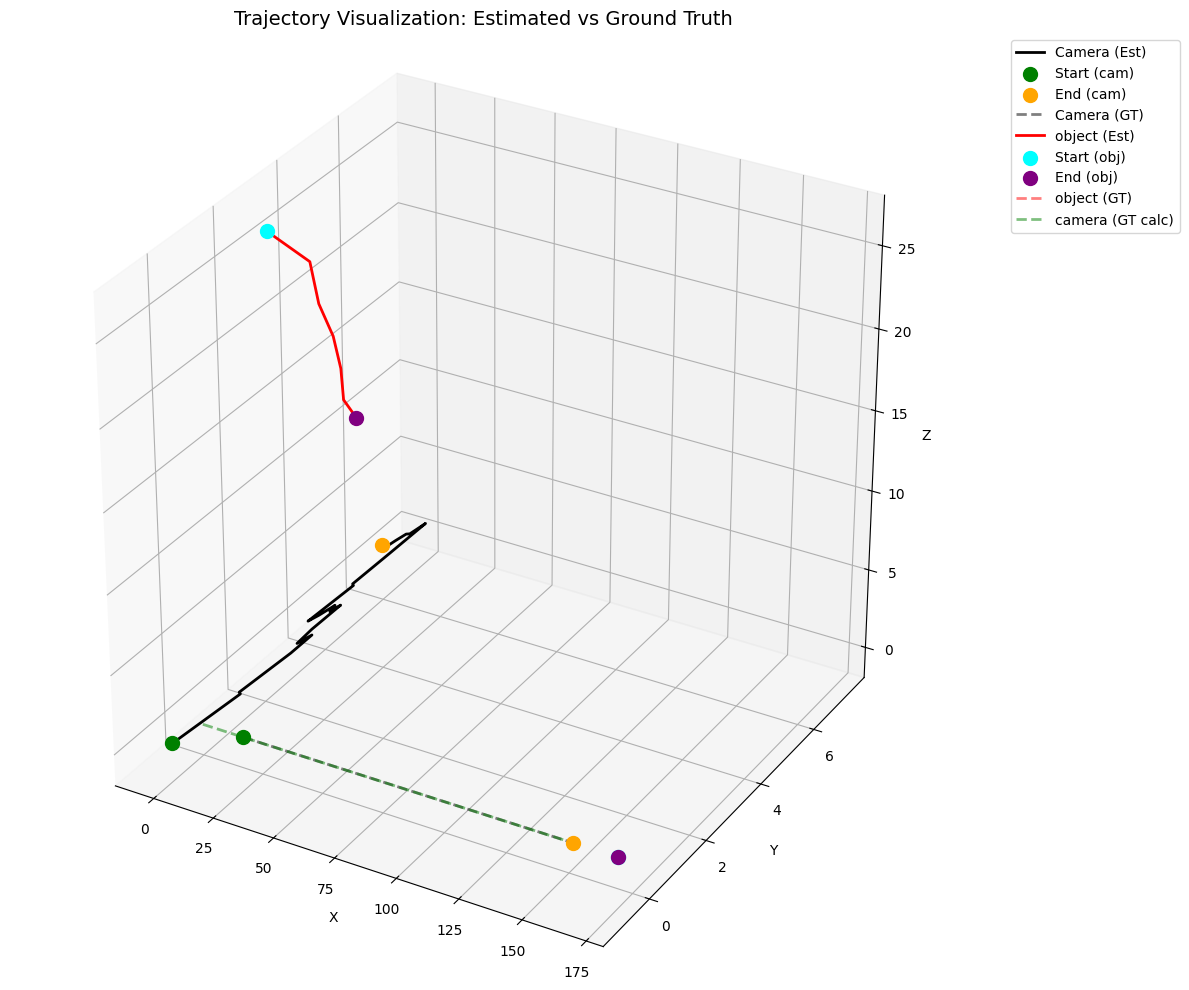

In [142]:
cam_file = f'{PATH}/../../results/Cheops_approach_top_p-45_y45_50_bg/frontend_camera_pose_log.csv'
obj_file = f'{PATH}/../../results/Cheops_approach_top_p-45_y45_50_bg/frontend_object_pose_log.csv'
raw_pose_file = f"{PATH}/../../tracking_dataset/Cheops_raw/Cheops/approach_top_p-45_y45/pose_ground_truth.csv"
visualize_trajectories(cam_file, obj_file, raw_pose_file)

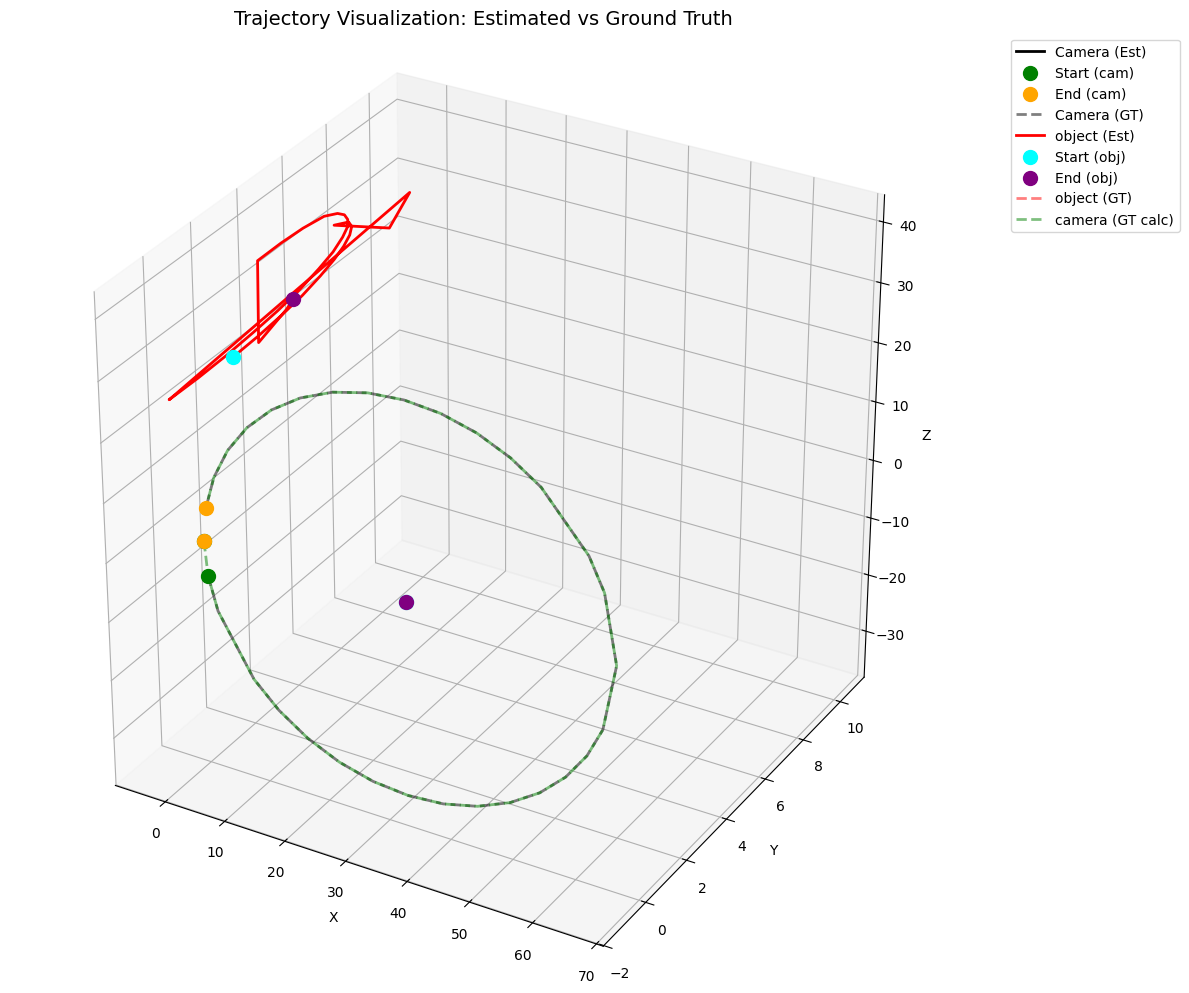

In [143]:
cam_file = f'{PATH}/../../results/Cheops_50_bg/frontend_camera_pose_log.csv'
obj_file = f'{PATH}/../../results/Cheops_50_bg/frontend_object_pose_log.csv'
raw_pose_file = f"{PATH}/../../tracking_dataset/Cheops_raw/Cheops/orbit_45deg_right_back/pose_ground_truth.csv"
visualize_trajectories(cam_file, obj_file, raw_pose_file)

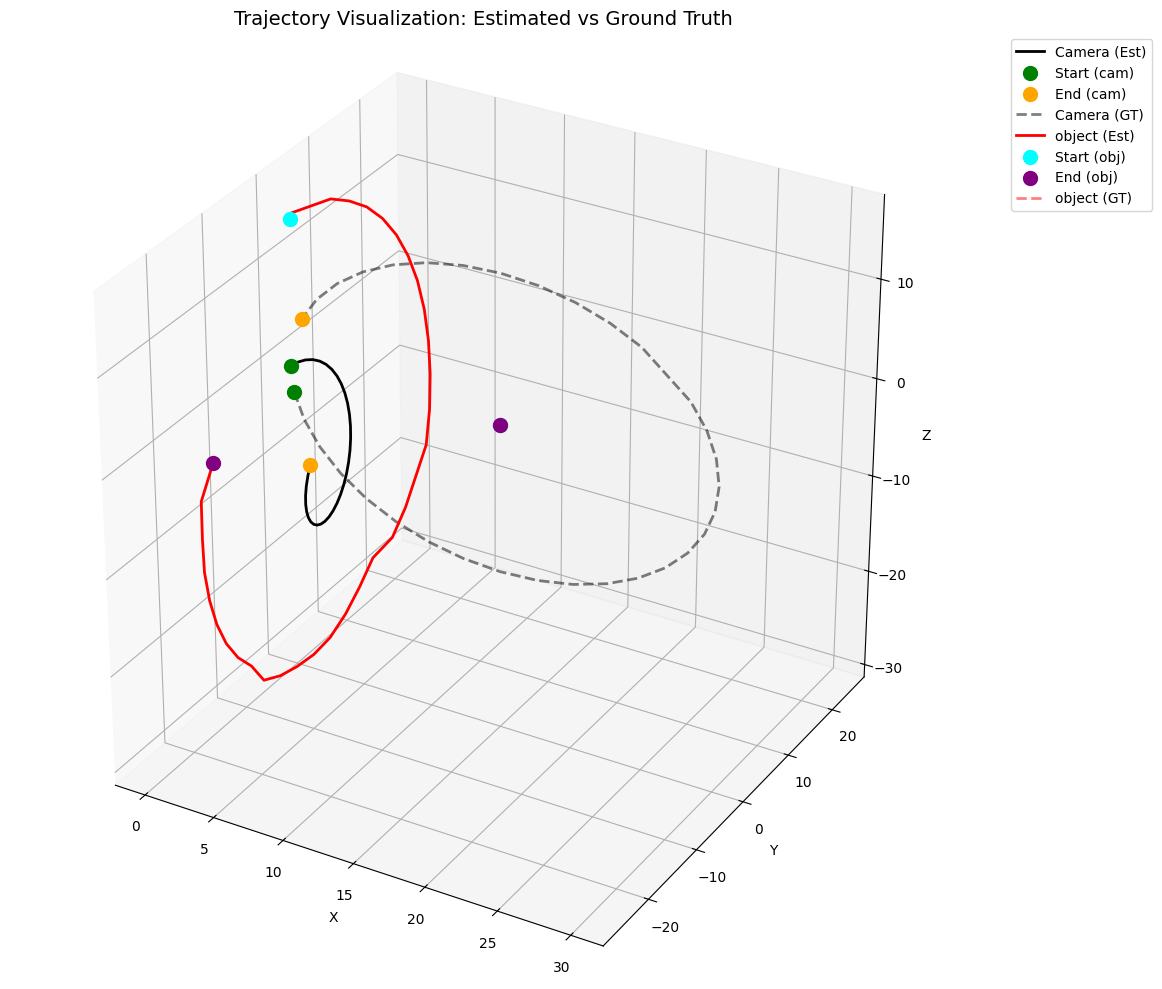

In [140]:
cam_file = f'{PATH}/../../results/ACE_50_bg/frontend_camera_pose_log.csv'
obj_file = f'{PATH}/../../results/ACE_50_bg/frontend_object_pose_log.csv'
raw_pose_file = f"{PATH}/../../tracking_dataset/ACE_raw/ACE/orbit_45deg_right_back/pose_ground_truth.csv"
visualize_trajectories(cam_file, obj_file, raw_pose_file)

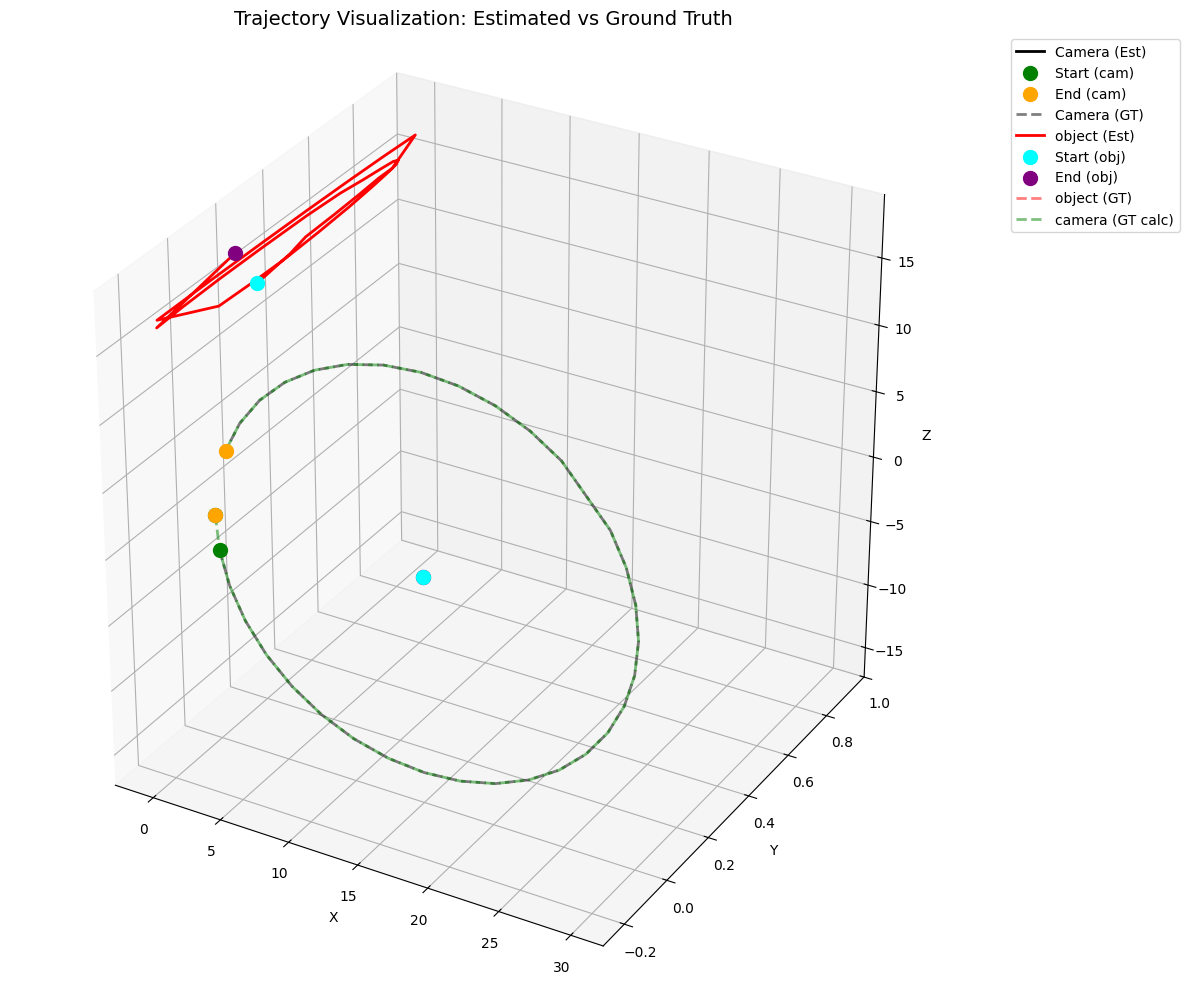

In [144]:
cam_file = f'{PATH}/../../results/ACE_500_bg/frontend_camera_pose_log.csv'
obj_file = f'{PATH}/../../results/ACE_500_bg/frontend_object_pose_log.csv'
raw_pose_file = f"{PATH}/../../tracking_dataset/ACE_raw/ACE/orbit_45deg_right_back/pose_ground_truth.csv"
visualize_trajectories(cam_file, obj_file, raw_pose_file)